# Machine Learning Analysis — Credit Card Approval Risk Prediction

## Story of this notebook

In the previous phases, we cleaned the customer data, created meaningful features, and explored customer risk patterns using EDA.

Now we are moving to the final phase: **Machine Learning Analysis**.

In this notebook, we will act like a data science team working for a bank. The bank wants to identify whether a credit card applicant is likely to be a **Good Customer** or a **Risky Customer**.

### What we will do in this notebook

1. Load the feature-engineered dataset  
2. Separate input features and target variable  
3. Split the data into training and testing sets  
4. Train multiple machine learning models  
5. Compare model performance  
6. Select the best model  
7. Understand important features  
8. Save the final model  
9. Write the final project conclusion

### Target meaning

- **TARGET = 0** → Good customer  
- **TARGET = 1** → Risky customer

## Step 1: Import required libraries

Before building the machine learning model, we first import the Python libraries required for data handling, model training, model evaluation, and visualization.

We are using simple and commonly used libraries:

- `pandas` and `numpy` for data handling
- `matplotlib` and `seaborn` for visualization
- `sklearn` for machine learning models and evaluation
- `joblib` for saving the final model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## Step 2: Load the feature-engineered dataset

At this stage, we are not starting from raw data again.

We already completed:

- Data cleaning
- Data merging
- Missing value handling
- Duplicate handling
- Target creation
- Feature engineering

So here we load the final feature-engineered dataset and use it for machine learning.

In [3]:
df = pd.read_csv('feature_engineered_credit_card_data.csv')

print('Dataset loaded successfully')
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

df.head()

Dataset loaded successfully
Rows: 36457
Columns: 68


,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,TARGET,TOTAL_MONTHS,MONTHS_ON_TIME,MONTHS_DELAYED,MAX_DELAY_STATUS,AGE,EMPLOYMENT_YEARS,INCOME_PER_FAMILY_MEMBER,HAS_CHILDREN,IS_EMPLOYED,EMPLOYMENT_TO_AGE_RATIO,OWN_CAR_FLAG,OWN_REALTY_FLAG,ASSET_SCORE,CONTACT_SCORE,ON_TIME_PAYMENT_RATIO,DELAYED_PAYMENT_RATIO,HAS_HIGH_DELAY,GENDER_MALE,EDUCATION_LEVEL,AGE_GROUP_ENCODED,INCOME_GROUP_ENCODED,FAMILY_SIZE_GROUP_ENCODED,CHILDREN_GROUP_ENCODED,EMPLOYMENT_GROUP_ENCODED,CREDIT_HISTORY_STRENGTH_ENCODED,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Working,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,0,427500.0,1,1,0,0,2.0,1,16,15,1,1,32,12,213750.0,0,1,0.375000,1,1,2,1,0.937500,0.062500,0,1,4,2,4,2,0,4,3,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,427500.0,1,1,0,0,2.0,1,15,14,1,1,32,12,213750.0,0,1,0.375000,1,1,2,1,0.933333,0.066667,0,1,4,2,4,2,0,4,3,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,112500.0,1,0,0,0,2.0,0,30,30,0,0,58,3,56250.0,0,1,0.051724,1,1,2,0,1.000000,0.000000,0,1,2,5,1,2,0,2,4,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,270000.0,1,0,1,1,1.0,0,5,5,0,0,52,8,270000.0,0,1,0.153846,0,1,1,2,1.000000,0.000000,0,0,2,4,4,1,0,3,1,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,270000.0,1,0,1,1,1.0,0,5,5,0,0,52,8,270000.0,0,1,0.153846,0,1,1,2,1.000000,0.000000,0,0,2,4,4,1,0,3,1,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


## Step 3: Quick check of the dataset

Before model training, we quickly check:

- Dataset size
- Missing values
- Target column availability
- Target class distribution

This helps us confirm that the data is ready for machine learning.

In [4]:
print('Dataset shape:', df.shape)
print('Missing values count:')
print(df.isnull().sum().sum())

print('Target distribution:')
print(df['TARGET'].value_counts())

print('Target distribution percentage:')
print((df['TARGET'].value_counts(normalize=True) * 100).round(2))

Dataset shape: (36457, 68)
Missing values count:
0
Target distribution:
TARGET
0    32166
1     4291
Name: count, dtype: int64
Target distribution percentage:
TARGET
0    88.23
1    11.77
Name: proportion, dtype: float64


## What the target distribution tells us

This tells us how many customers are good and how many are risky.

In credit risk datasets, usually the number of good customers is much higher than risky customers. This is called **class imbalance**.

Because of this, we should not depend only on accuracy. We also need to check:

- Precision
- Recall
- F1-score
- Confusion matrix

These metrics give a better understanding of how well the model identifies risky customers.

## Step 4: Separate features and target

Machine learning needs two parts:

- `X` → input features used to make predictions
- `y` → target variable we want to predict

Here, `TARGET` is our output column, so we remove it from the input features.

In [22]:
feature_engineered_cols = [
    "TOTAL_MONTHS",
    "MONTHS_ON_TIME",
    "MONTHS_DELAYED",
    "MAX_DELAY_STATUS",
    "INCOME_PER_FAMILY_MEMBER",
    "HAS_CHILDREN",
    "IS_EMPLOYED",
    "EMPLOYMENT_TO_AGE_RATIO",
    "ASSET_SCORE",
    "CONTACT_SCORE",
    "ON_TIME_PAYMENT_RATIO",
    "DELAYED_PAYMENT_RATIO",
    "HAS_HIGH_DELAY",
    "AGE_GROUP_ENCODED",
    "INCOME_GROUP_ENCODED",
    "FAMILY_SIZE_GROUP_ENCODED",
    "CHILDREN_GROUP_ENCODED",
    "EMPLOYMENT_GROUP_ENCODED",
    "CREDIT_HISTORY_STRENGTH_ENCODED"
]

X = df.drop(columns=feature_engineered_cols + ["TARGET"])
y = df["TARGET"]

In [23]:
X

,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,EMPLOYMENT_YEARS,OWN_CAR_FLAG,OWN_REALTY_FLAG,GENDER_MALE,EDUCATION_LEVEL,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Working,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,0,427500.0,1,1,0,0,2.0,32,12,1,1,1,4,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,427500.0,1,1,0,0,2.0,32,12,1,1,1,4,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,112500.0,1,0,0,0,2.0,58,3,1,1,1,2,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,270000.0,1,0,1,1,1.0,52,8,0,1,0,2,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,270000.0,1,0,1,1,1.0,52,8,0,1,0,2,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,0,315000.0,1,0,0,0,2.0,47,6,1,1,1,2,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
36453,0,157500.0,1,0,1,1,2.0,33,3,0,1,0,4,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
36454,0,157500.0,1,0,1,1,2.0,33,3,0,1,0,4,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
36455,0,283500.0,1,0,0,0,2.0,49,1,0,1,0,2,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


## Step 5: Train-test split

We split the data into two parts:

- **Training data** → used to train the model
- **Testing data** → used to check how the model performs on unseen data

We use `stratify=y` so that both train and test sets have a similar percentage of good and risky customers.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Training data shape: (29165, 48)
Testing data shape: (7292, 48)


## Step 6: Create machine learning models

We will train three models:

### 1. Logistic Regression
A simple and explainable model. It is useful as a baseline model.

### 2. Decision Tree
A rule-based model that learns decision paths like a flowchart.

### 3. Random Forest
A stronger model that combines many decision trees to improve prediction performance.

We use `class_weight='balanced'` because the dataset has more good customers than risky customers.

In [25]:
models = {
    'Logistic Regression': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=30,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        min_samples_split=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

print('Models created successfully')

Models created successfully


## Step 7: Train and evaluate all models

Now we train each model on the training data and test it on the testing data.

For each model, we calculate:

- **Accuracy**: Overall correct predictions
- **Precision**: Out of predicted risky customers, how many were actually risky
- **Recall**: Out of actual risky customers, how many the model found
- **F1 Score**: Balance between precision and recall
- **ROC-AUC**: Overall separation power between good and risky customers

For credit risk projects, **recall and F1-score are very important** because missing risky customers can create financial loss for the bank.

In [26]:
results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.8055,0.2863,0.4371,0.3459,0.7129
1,Decision Tree,0.5815,0.1473,0.5338,0.2308,0.5879
0,Logistic Regression,0.5666,0.1369,0.5058,0.2155,0.5486


## Step 8: Visual comparison of model performance

A table is useful, but a graph makes it easier to compare models quickly.

Here we compare models using F1 Score because it balances both precision and recall.

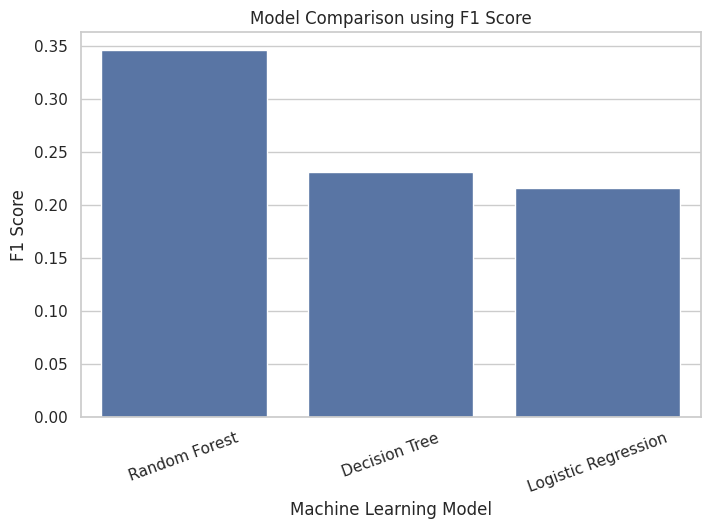

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Model', y='F1 Score')
plt.title('Model Comparison using F1 Score')
plt.xlabel('Machine Learning Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=20)
plt.show()

## What this graph is telling

This graph compares the models using **F1 Score**.

The model with the highest F1 Score is considered better because it creates a good balance between:

- Finding risky customers correctly
- Avoiding too many wrong risky predictions

For this credit card approval project, the best model should not only be accurate, but should also identify risky customers properly.

## Step 9: Select the best model

Here we automatically select the model with the highest F1 Score.

We are using F1 Score because the dataset is imbalanced and because identifying risky customers correctly is more important than simply getting high accuracy.

In [29]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print('Best Model:', best_model_name)
print('Best Model Performance:')
display(results_df.iloc[[0]].round(4))

Best Model: Random Forest
Best Model Performance:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.8055,0.2863,0.4371,0.3459,0.7129


## Step 10: Confusion matrix of the best model

The confusion matrix helps us understand the model predictions in a very practical way.

It shows:

- Good customers predicted as good
- Good customers wrongly predicted as risky
- Risky customers wrongly predicted as good
- Risky customers predicted as risky

For a bank, the most dangerous error is predicting a risky customer as good.

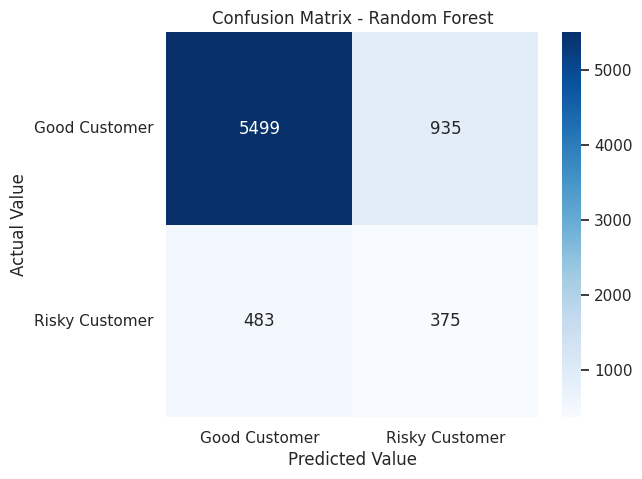

Confusion Matrix:
[[5499  935]
 [ 483  375]]


In [30]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.xticks([0.5, 1.5], ['Good Customer', 'Risky Customer'])
plt.yticks([0.5, 1.5], ['Good Customer', 'Risky Customer'], rotation=0)
plt.show()

print('Confusion Matrix:')
print(cm)

## What the confusion matrix is telling

The confusion matrix shows how well the model separates good customers and risky customers.

### Business meaning

- If the model correctly identifies risky customers, the bank can reduce financial loss.
- If the model wrongly approves risky customers, the bank may face repayment problems.
- If the model wrongly rejects good customers, the bank may lose potential business.

So the bank must balance risk control and customer approval.

## Step 11: Classification report

The classification report gives detailed performance for each class:

- Class 0 → Good customers
- Class 1 → Risky customers

This helps us see whether the model performs well for both groups.

In [31]:
print(f'Classification Report for {best_model_name}:')
print(classification_report(y_test, y_pred_best, target_names=['Good Customer', 'Risky Customer']))

Classification Report for Random Forest:
                precision    recall  f1-score   support

 Good Customer       0.92      0.85      0.89      6434
Risky Customer       0.29      0.44      0.35       858

      accuracy                           0.81      7292
     macro avg       0.60      0.65      0.62      7292
  weighted avg       0.84      0.81      0.82      7292



## Step 12: Cross-validation check

Cross-validation checks whether the model performance is stable.

Instead of training and testing only once, cross-validation trains and tests the model multiple times on different parts of the data.

This helps us know whether the model is reliable or only performed well by chance.

In [32]:
cv_scores = cross_val_score(best_model, X, y, cv=3, scoring='f1', n_jobs=-1)

print('Cross-validation F1 scores:', cv_scores.round(4))
print('Average CV F1 Score:', cv_scores.mean().round(4))

Cross-validation F1 scores: [0.134  0.1005 0.1427]
Average CV F1 Score: 0.1257


## Step 13: Feature importance

Now we try to understand which features helped the model make decisions.

If the best model is Random Forest or Decision Tree, we can directly check feature importance.

If the best model is Logistic Regression, we can check the absolute coefficient values.

This step is important because a machine learning project should not only predict, but also explain the reasons behind predictions.

In [33]:
if best_model_name in ['Random Forest', 'Decision Tree']:
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(15)
else:
    lr_model = best_model.named_steps['model']
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': np.abs(lr_model.coef_[0])
    }).sort_values(by='Importance', ascending=False).head(15)

importance_df

,Feature,Importance
7,AGE,0.143398
1,AMT_INCOME_TOTAL,0.136913
8,EMPLOYMENT_YEARS,0.110467
6,CNT_FAM_MEMBERS,0.047613
12,EDUCATION_LEVEL,0.040191
0,CNT_CHILDREN,0.038515
10,OWN_REALTY_FLAG,0.028169
9,OWN_CAR_FLAG,0.027759
4,FLAG_PHONE,0.025517
11,GENDER_MALE,0.022583


## Step 14: Visualize top important features

This graph helps us clearly see which features contributed most to the model.

In credit risk analysis, features related to payment delays are usually expected to be very important because past repayment behavior is a strong indicator of future risk.

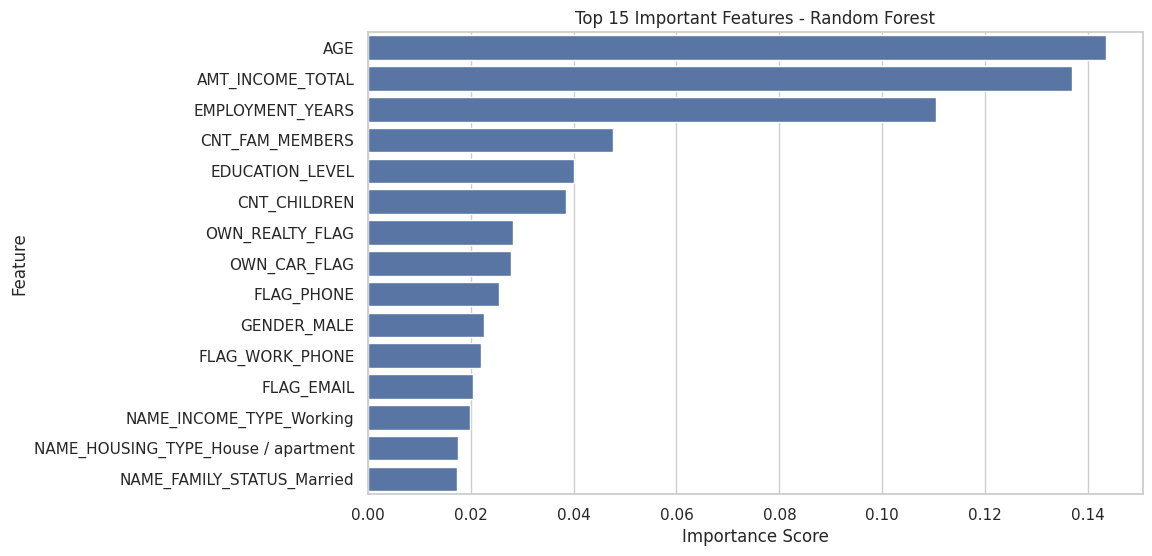

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title(f'Top 15 Important Features - {best_model_name}')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## Step 15: Save the final model

After selecting the best model, we save it using `joblib`.

This saved model can later be reused for prediction without training again.

In [35]:
joblib.dump(best_model, 'final_credit_card_risk_model.pkl')
print('Final model saved as final_credit_card_risk_model.pkl')

Final model saved as final_credit_card_risk_model.pkl


# Final Project Conclusion

## Complete project story

This project was built to help a bank make better credit card approval decisions.

The bank's main problem was:

> How can we identify risky customers before approving credit cards?

To solve this problem, we worked through the complete data analysis and machine learning pipeline.

### What we completed

1. **Data Understanding**  
   We studied customer application records and repayment history records.

2. **Data Cleaning and Preprocessing**  
   We checked data types, missing values, duplicates, and cleaned the dataset.

3. **Target Variable Creation**  
   We converted repayment status into a clear target:
   - `0` = Good Customer
   - `1` = Risky Customer

4. **Data Merging**  
   We merged customer application data with credit repayment history using customer ID.

5. **Exploratory Data Analysis**  
   We studied risk patterns across income type, education, family status, age, income, and repayment behavior.

6. **Feature Engineering**  
   We created meaningful features such as age, employment years, income per family member, payment delay features, and credit history strength.

7. **Machine Learning Analysis**  
   We trained and compared Logistic Regression, Decision Tree, and Random Forest models.

## Main business finding

The most important finding is:

> Repayment behavior is much more important than demographic information for predicting credit card risk.

Features related to payment delay were the strongest indicators of whether a customer is risky.

## Final recommendation to the bank

The bank should not approve or reject customers based only on income, education, family status, or age.

Instead, the bank should give stronger importance to:

- Maximum delay status
- Number of delayed months
- Delayed payment ratio
- On-time payment ratio
- Credit history strength

## Final result

The final machine learning model can help the bank identify risky applicants more effectively and support better credit card approval decisions.

This makes the project useful for real-world credit risk analysis and suitable for a Data Analyst/Data Science portfolio.